In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported!")

All libraries imported!


In [6]:
from google.colab import files
import io

print("Click 'Choose Files' and select q3_retail_promotions.csv")
uploaded = files.upload()

df = pd.read_csv(io.BytesIO(uploaded['q3_retail_promotions.csv']))

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Click 'Choose Files' and select q3_retail_promotions.csv


Saving q3_retail_promotions.csv to q3_retail_promotions.csv
Shape: (1200, 9)

First 5 rows:
  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  
0           1            0                    5         224  
1           1            1                    1         348  
2           1            0                    6         249  
3           1            0                    7         259  
4           0            0                    3         277  

Data types:
transaction_date       object
store_id                int64
store_size             o

In [7]:
# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract date features
df['year']         = df['transaction_date'].dt.year
df['month']        = df['transaction_date'].dt.month
df['day_of_week']  = df['transaction_date'].dt.dayofweek   # 0=Monday, 6=Sunday

# Create is_month_end: 1 if day of month >= 25, else 0
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("✅ Date features created. Sample:")
print(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10))

✅ Date features created. Sample:
  transaction_date  year  month  day_of_week  is_month_end
0       2022-01-01  2022      1            5             0
1       2022-01-01  2022      1            5             0
2       2022-01-02  2022      1            6             0
3       2022-01-02  2022      1            6             0
4       2022-01-03  2022      1            0             0
5       2022-01-03  2022      1            0             0
6       2022-01-04  2022      1            1             0
7       2022-01-04  2022      1            1             0
8       2022-01-05  2022      1            2             0
9       2022-01-05  2022      1            2             0


In [10]:
# Sort by date (most important!)
df = df.sort_values('transaction_date').reset_index(drop=True)

# Use the most recent 20% as test set
split_idx = int(len(df) * 0.80)
train_df  = df.iloc[:split_idx].copy()
test_df   = df.iloc[split_idx:].copy()

print(f"✅ Train size: {len(train_df)} rows")
print(f"   Test  size: {len(test_df)} rows")
print(f"\nTrain date range: {train_df['transaction_date'].min()} → {train_df['transaction_date'].max()}")
print(f"Test  date range: {test_df['transaction_date'].min()} → {test_df['transaction_date'].max()}")

✅ Train size: 960 rows
   Test  size: 240 rows

Train date range: 2022-01-01 00:00:00 → 2024-06-11 00:00:00
Test  date range: 2024-06-12 00:00:00 → 2024-12-31 00:00:00


## Why Random Split is Inappropriate for Time-Series Data (Markdown Cell)

In a random split, future data can end up in the training set, which means the model
is "trained on the future". This leads to **data leakage** — the model learns patterns
that would not be available in a real deployment scenario, resulting in over-optimistic
evaluation scores.

**The correct approach** is a temporal split: train on older data, test on newer data.
This simulates real-world forecasting — you predict next month's sales based only on
what you knew before that month. Temporal splits prevent data leakage and ensure
evaluation metrics reflect true generalisation ability.

In [11]:
# Drop transaction_date (already extracted into features)
cat_features = ['promotion_type', 'location_type', 'store_size']
num_features = ['year', 'month', 'day_of_week', 'is_month_end',
                'is_weekend', 'is_festival', 'competition_density', 'store_id']

target = 'items_sold'

X_train = train_df[cat_features + num_features]
y_train = train_df[target]
X_test  = test_df[cat_features + num_features]
y_test  = test_df[target]

print(f"✅ Feature sets defined.")
print(f"   Categorical: {cat_features}")
print(f"   Numerical:   {num_features}")

✅ Feature sets defined.
   Categorical: ['promotion_type', 'location_type', 'store_size']
   Numerical:   ['year', 'month', 'day_of_week', 'is_month_end', 'is_weekend', 'is_festival', 'competition_density', 'store_id']


In [12]:
# ColumnTransformer: different preprocessing per feature type
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ('num', StandardScaler(), num_features)
])

print("✅ ColumnTransformer preprocessor defined!")
print("   - OneHotEncoder → categorical features")
print("   - StandardScaler → numerical features")

✅ ColumnTransformer preprocessor defined!
   - OneHotEncoder → categorical features
   - StandardScaler → numerical features


In [13]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)

print("📊 Linear Regression Results:")
print(f"   RMSE : {rmse_lr:.2f}")
print(f"   MAE  : {mae_lr:.2f}")

📊 Linear Regression Results:
   RMSE : 27.12
   MAE  : 21.05


In [14]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)

print("📊 Random Forest Regressor Results:")
print(f"   RMSE : {rmse_rf:.2f}")
print(f"   MAE  : {mae_rf:.2f}")

# Comparison table
print("\n📋 Model Comparison:")
comparison_df = pd.DataFrame({
    'Model':            ['Linear Regression', 'Random Forest'],
    'RMSE (lower=better)': [round(rmse_lr, 2), round(rmse_rf, 2)],
    'MAE  (lower=better)': [round(mae_lr, 2),  round(mae_rf, 2)]
})
print(comparison_df.to_string(index=False))

📊 Random Forest Regressor Results:
   RMSE : 30.56
   MAE  : 23.95

📋 Model Comparison:
            Model  RMSE (lower=better)  MAE  (lower=better)
Linear Regression                27.12                21.05
    Random Forest                30.56                23.95


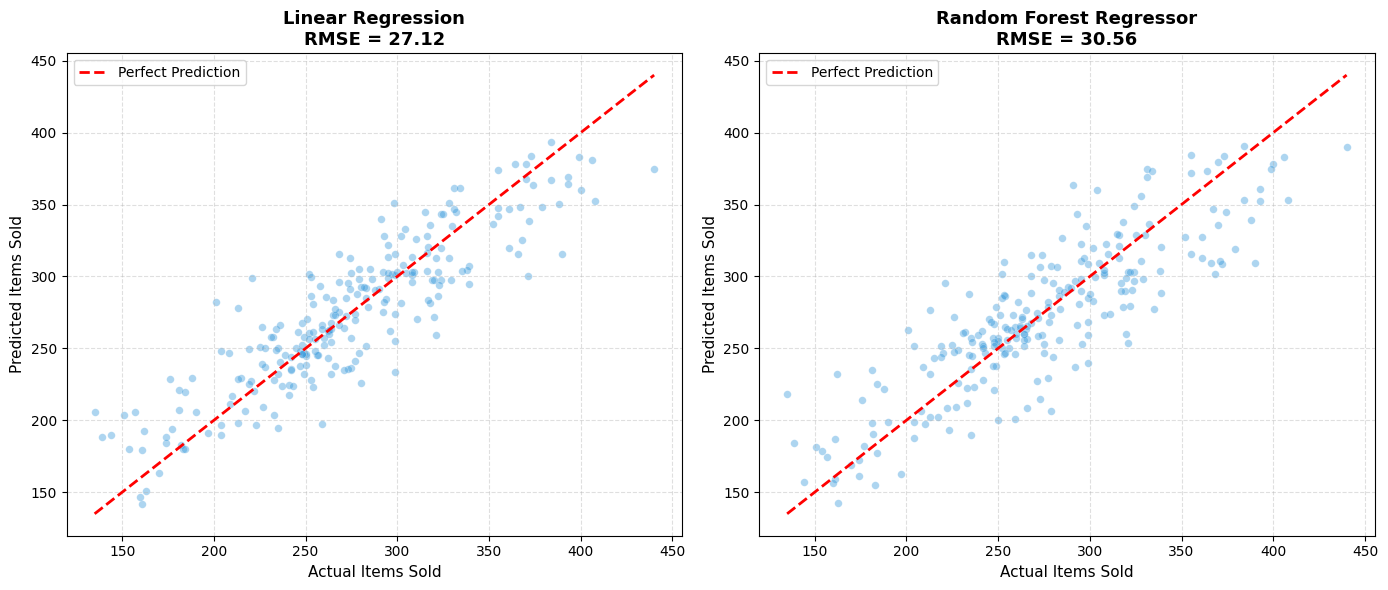

✅ Parity plots saved!


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title, rmse in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest Regressor'],
    [rmse_lr, rmse_rf]
):
    ax.scatter(y_test, y_pred, alpha=0.4, color='#3498db',
               edgecolors='white', linewidths=0.3, s=30)

    # Diagonal reference line (perfect prediction)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', linewidth=2, label='Perfect Prediction')

    ax.set_title(f'{title}\nRMSE = {rmse:.2f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Actual Items Sold', fontsize=11)
    ax.set_ylabel('Predicted Items Sold', fontsize=11)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('q3_parity_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Parity plots saved!")

📊 Top 10 Feature Importances:
            Feature  Importance
        is_festival    0.173454
   store_size_small    0.167183
location_type_urban    0.108432
        day_of_week    0.087752
         is_weekend    0.059848
           store_id    0.054997
location_type_rural    0.053589
competition_density    0.050755
   store_size_large    0.048696
              month    0.037117


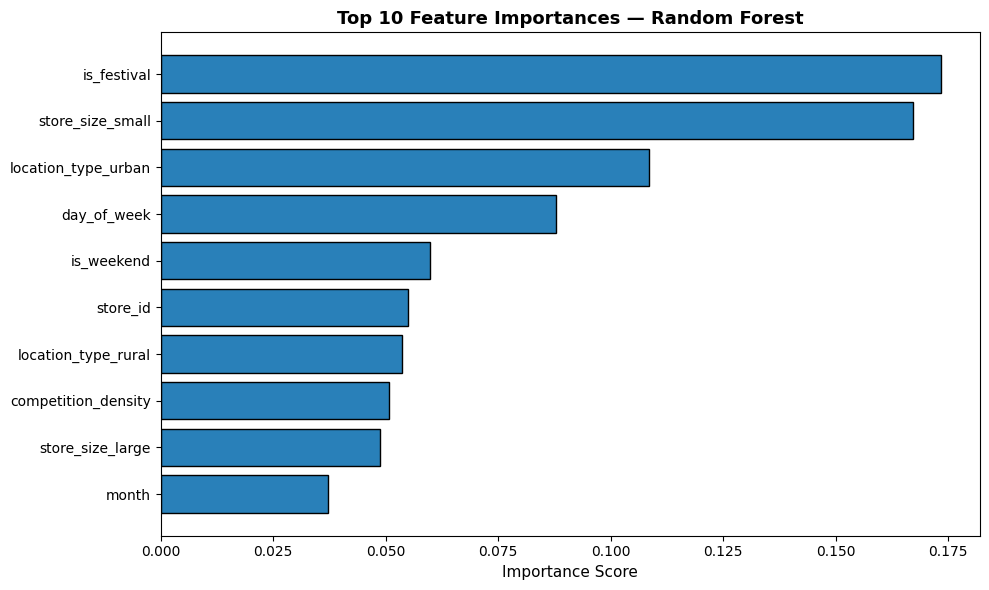


🏆 Top 5 Most Influential Features:
            Feature  Importance
        is_festival    0.173454
   store_size_small    0.167183
location_type_urban    0.108432
        day_of_week    0.087752
         is_weekend    0.059848

 Q3 Complete!


In [17]:
# Get feature names after one-hot encoding
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(cat_features).tolist()
all_feature_names = ohe_feature_names + num_features

# Extract importances
importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("📊 Top 10 Feature Importances:")
print(feat_imp_df.head(10).to_string(index=False))

# Bar chart of top 10
plt.figure(figsize=(10, 6))
top10 = feat_imp_df.head(10)
plt.barh(top10['Feature'][::-1], top10['Importance'][::-1],
         color='#2980b9', edgecolor='black')
plt.title('Top 10 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score', fontsize=11)
plt.tight_layout()
plt.savefig('q3_feature_importances.png', dpi=150)
plt.show()

print(f"\n🏆 Top 5 Most Influential Features:")
print(feat_imp_df.head(5)[['Feature', 'Importance']].to_string(index=False))
print("\n Q3 Complete!")